# Multidomain CLARA tutorial: IDCD (Independence from Domain Costs and Distances)

This notebook reproduces the **empirical application** in the MD-CLARA paper (Section 5) for the **IDCD** route. It uses the same two-domain LinkedIn life-course sample as the CAT and DAT tutorials:

1. **Occupation** — technical computing occupation categories over 10 work years  
2. **Seniority** — seniority levels over the same window  

Under IDCD, domain states are combined at each time point (e.g. `Software+Senior`) and OM is applied to the resulting multidomain sequences. **MD-CLARA** embeds this strategy in CLARA's sample-and-assign procedure so the full `N × N` distance object is never stored.

**Diagnostics covered here (beyond cluster quality and stability):**

- Combined multidomain **state-space sparsity** (`summarize_combined_state_space`)  
- **Leave-one-domain-out** stability (ARI vs the all-domain typology)  

For **cross-strategy agreement** (IDCD vs CAT vs DAT on the same data), see `md_clara_cross_strategy_diagnostics.ipynb`.

**Prerequisites:** Sequenzo with `sequenzo.multidomain.clara`; CSV files in `data/`. Set `TUTORIAL_SUBSET_N = 2000` in Step 1 for a faster first run.

With **two domains**, omitting one leaves a single domain; Sequenzo then fits standard single-domain CLARA (`reduced_model='clara_single_domain'`) for that row. ARI still compares partitions on the same individuals.

## Step 1 — Imports and paths

In [1]:
# --- Paths (edit if your Sequenzo install lives elsewhere) ---
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
# 若 cwd 不是 xinyi_test，则定位到 notebook 所在目录
if (NOTEBOOK_DIR / "data").is_dir():
    pass  # 已在 xinyi_test
elif (NOTEBOOK_DIR / "tests/archive_test/xinyi_test/data").is_dir():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "tests/archive_test/xinyi_test"
else:
    NOTEBOOK_DIR = Path(__file__).resolve().parent  # 若在 .py 中

DATA_DIR = NOTEBOOK_DIR / "data"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for candidate in (
    NOTEBOOK_DIR.parents[1] / "Sequenzo",
    NOTEBOOK_DIR.parent / "Sequenzo",
):
    if candidate.is_dir() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))
        break



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sequenzo import SequenceData, plot_sequence_index
from sequenzo.multidomain import get_association_between_domains
from sequenzo.multidomain.clara import (
    md_clara,
    plot_md_clara_quality,
    summarize_combined_state_space,
    leave_one_domain_out_sensitivity,
    plot_leave_one_domain_out_sensitivity,
)

DOMAIN_NAMES = ["occupation", "seniority"]

# CLARA tuning (paper-style: b = min(1000, max(40+2K, 0.4N)); R=50 in benchmarks)
CLARA_R = 25
CLARA_R_DIAG = 15  # fewer repetitions for leave-one-domain-out checks


def clara_sample_size(n_cases: int, max_k: int = 10) -> int:
    return min(1000, max(40 + 2 * max_k, int(0.4 * n_cases)))


# Set to an integer (e.g. 2000) for a quick dry run; None uses the full sample.
TUTORIAL_SUBSET_N = None
RANDOM_STATE = 42


## Step 2 — Load and align the two domain datasets

Both CSV files share `worker_id`. We keep the intersection and sort rows so that row *i* in occupation matches row *i* in seniority.

In [2]:
OCCUPATION_CSV = DATA_DIR / "detailed_sequence_10_work_years_df_clean_year_names_column.csv"
SENIORITY_CSV = DATA_DIR / "detailed_senority_levels_for_10_years_clean_year_names_column.csv"

occupation_df = pd.read_csv(OCCUPATION_CSV)
seniority_df = pd.read_csv(SENIORITY_CSV)

common_ids = np.intersect1d(occupation_df["worker_id"], seniority_df["worker_id"])
occupation_df = (
    occupation_df[occupation_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
seniority_df = (
    seniority_df[seniority_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
assert (occupation_df["worker_id"].values == seniority_df["worker_id"].values).all()

if TUTORIAL_SUBSET_N is not None:
    occupation_df = occupation_df.head(TUTORIAL_SUBSET_N).copy()
    seniority_df = seniority_df.head(TUTORIAL_SUBSET_N).copy()

print(f"Individuals: {len(occupation_df):,}")
occupation_df.head()


Individuals: 32,628


,worker_id,gender,country,cohort,1,2,3,4,5,6,7,8,9,10
0,%C2%BBkiran-mummala-narayana-68aaba89,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
1,%E2%86%92-jeremy-mikkola-14455832,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
2,%E2%97%8F%E0%B9%8B-b%C3%A1%DA%A9t%C3%BD%C3%A1v...,male,india,11-20 total work years,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science,Data science
3,%E5%A4%A7%E4%BB%BB-%E9%99%B3-880a24110,male,us,11-20 total work years,Software,Software,Software,Software,Software,Software,Software,Software,Software,Software
4,%EF%BF%BDgary-m-762b16b8,male,us,21-30 total work years,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware,Hardware


## Step 3 — Color palettes

We reuse the custom state colors from the original LinkedIn sequence-analysis notebook (`250814.ipynb`) for **domain-level** index plots. Combined-state IDCD sequences use Sequenzo's default palette unless you define custom colors for every observed combination.

In [3]:
# Color palettes from the original LinkedIn sequence-analysis notebook (250814.ipynb).
# One hex code per state, in the same order as OCCUPATION_STATES / SENIORITY_STATES.

OCCUPATION_COLORS = [
    "#659F9F",  # Data
    "#4CA7A7",  # Data science
    "#6BB8C8",  # Software
    "#8CC9E0",  # Hardware
    "#B2C95E",  # Systems & infrastructure
    "#D7D97F",  # Research
    "#E8E1B4",  # Support & test
]

SENIORITY_COLORS = [
    "#E7D4EA",  # Assistant/Junior
    "#D8898C",  # Regular
    "#E14C48",  # Senior
    "#A64F91",  # Leader
    "#6A3D8C",  # Chief/founder
]


## Step 4 — Build `SequenceData` objects

Each domain is a wide table: one row per worker, columns `1`…`10` for years.

In [4]:
TIME_COLS = [str(i) for i in range(1, 11)]

OCCUPATION_STATES = [
    "Data",
    "Data science",
    "Software",
    "Hardware",
    "Systems & infrastructure",
    "Research",
    "Support & test",
]
SENIORITY_STATES = [
    "Assistant/Junior",
    "Regular",
    "Senior",
    "Leader",
    "Chief/founder",
]

occupation_seq = SequenceData(
    data=occupation_df,
    id_col="worker_id",
    time=TIME_COLS,
    states=OCCUPATION_STATES,
    custom_colors=OCCUPATION_COLORS,
)

seniority_seq = SequenceData(
    data=seniority_df,
    id_col="worker_id",
    time=TIME_COLS,
    states=SENIORITY_STATES,
    custom_colors=SENIORITY_COLORS,
)

domains = [occupation_seq, seniority_seq]
domain_names = ["occupation", "seniority"]

print(f"Domain 1 (occupation): {occupation_seq.seqdata.shape[0]:,} sequences")
print(f"Domain 2 (seniority):  {seniority_seq.seqdata.shape[0]:,} sequences")


[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Labels: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Void: '%' (not in states (inactive); not observed in data) — out-of-window padding; SAMM/seqsamm drops subsequences containing void
[>] Weights: Not provided
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Assistant/Junior', 'Re

## Step 5 — Explore each domain separately (optional)

Quick sanity check: plot the marginal sequence index for each domain.

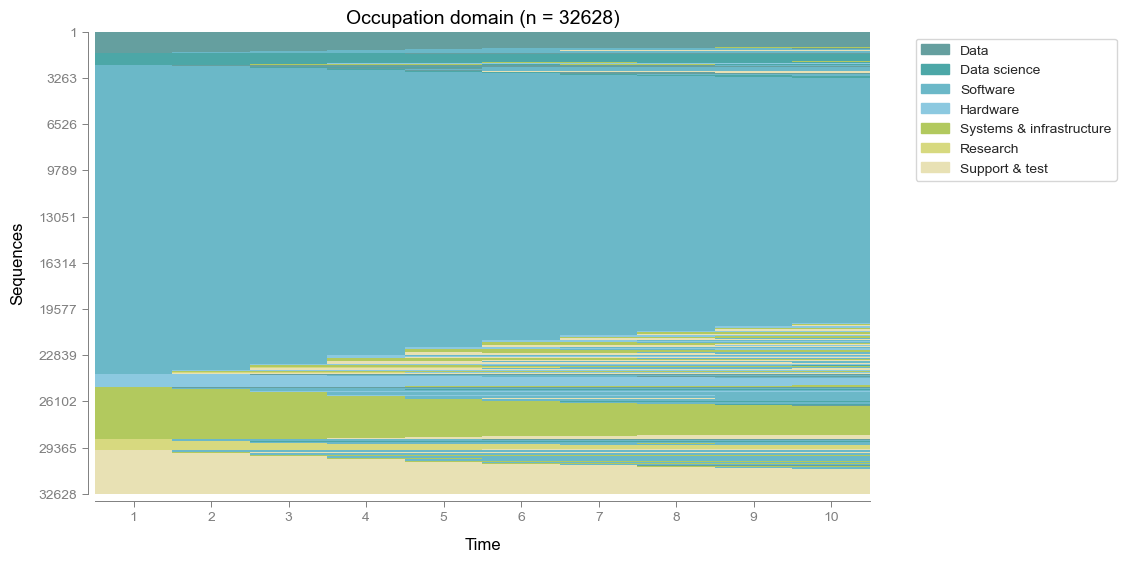

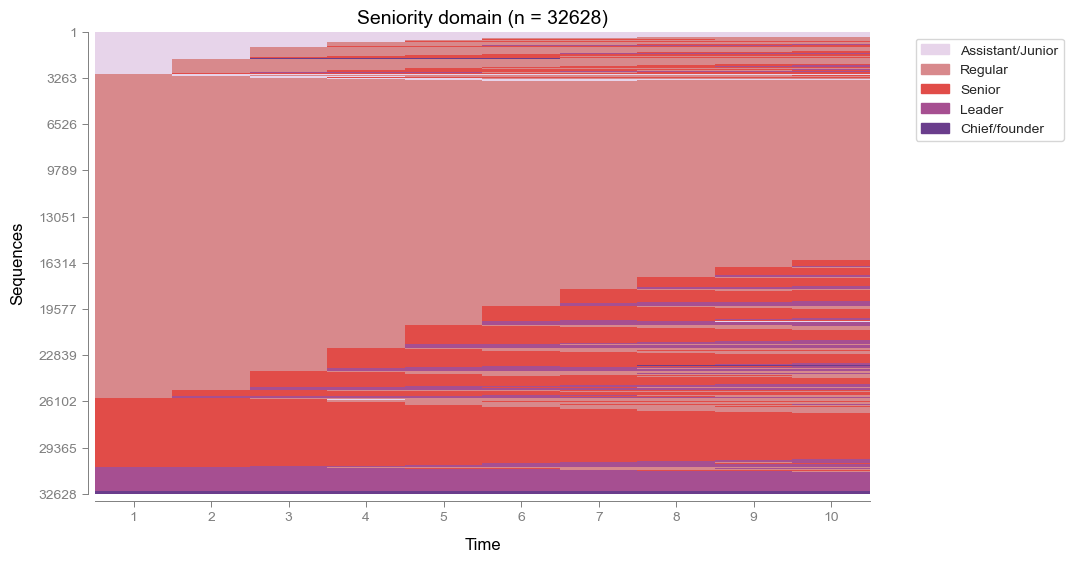

In [5]:
# Uncomment to plot the full sample (can be slow with ~32k rows).
plot_sequence_index(seqdata=occupation_seq, title="Occupation domain")
plot_sequence_index(seqdata=seniority_seq, title="Seniority domain")


## Step 6 — Measure association between domains

Unlike CAT and DAT, IDCD does **not** impose additive independence assumptions. Still, checking domain association helps interpret how occupation and seniority co-occur.

In [6]:
assoc = get_association_between_domains(
    domains,
    assoc=("LRT", "V"),
    dnames=domain_names,
    explain=True,
)
assoc



📜 Full results table:


,df,LRT,p(LRT),v,p(v),strength
occupation vs seniority,24.0,17434.505964,0.000 ***,0.141299,0.000 ***,Weak



📘 Column explanations:
  - df       : Degrees of freedom for the test (typically 1 for binary state sequences).
  - LRT      : Likelihood Ratio Test statistic (higher = stronger dependence).
  - p(LRT)   : p-value for LRT + significance stars: * (p<.05), ** (p<.01), *** (p<.001)
  - v        : Cramer's V statistic (0 to 1, measures association strength).
  - p(v)     : p-value for Cramer's V (based on chi-squared test) + significance stars: * (p<.05), ** (p<.01), *** (p<.001)
  - strength : Qualitative label for association strength based on Cramer's V:
               0.00-0.09 -> None, 0.10-0.29 -> Weak, 0.30-0.49 -> Moderate, >=0.50 -> Strong


## Step 7 — Combined multidomain state space (IDCD / CAT preview)

Before clustering, inspect how sparse the **observed** combined-state alphabet is relative to the theoretical product space. This matters for IDCD interpretation and is reported in the paper's empirical diagnostics.

In [7]:
state_space = summarize_combined_state_space(domains, ch_sep="+")
print(
    f"Theoretical combined states: {state_space['theoretical_combined_states']:,}"
)
print(f"Observed combined states:   {state_space['observed_combined_states']:,}")
print(f"Coverage: {state_space['coverage']:.1%}")
print(f"Rare states (<{state_space['rare_threshold']} cases): {state_space['rare_state_share']:.1%}")
print("\nTop combined states (by case frequency):")
pd.DataFrame(state_space["top_combined_states"]).head(8)


[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Software+Regular', 'Software+Senior', 'Systems & infrastructure+Regular', 'Support & test+Regular', 'Software+Leader', 'Data+Regular', 'Systems & infrastructure+Senior', 'Support & test+Senior', 'Support & test+Leader', 'Data science+Regular', 'Hardware+Regular', 'Software+Assistant/Junior', 'Systems & infrastructure+Leader', 'Data+Senior', 'Research+Regular', 'Hardware+Leader', 'Hardware+Senior', 'Data+Leader', 'Data science+Senior', 'Research+Assistant/Junior', 'Hardware+Assistant/Junior', 'Data science+Leader', 'Systems & infrastructure+Assistant/Junior', 'Software+Chief/founder', 'Support & test+Assistant/Junior', 'Research+Senior', 'Systems & infrastructure+Chief/founder', 'Data+Assistant/J

,state,case_frequency,position_frequency
0,Software+Regular,19933.0,133077.0
1,Software+Senior,11607.0,60933.0
2,Systems & infrastructure+Regular,3908.0,22760.0
3,Support & test+Regular,3323.0,17505.0
4,Software+Leader,3091.0,14257.0
5,Software+Assistant/Junior,2282.0,5621.0
6,Data+Regular,1670.0,9914.0
7,Support & test+Senior,1480.0,7075.0


## Step 8 — Configure IDCD distance parameters

Under IDCD, a **single** distance specification is applied to the combined-state sequences. We use classical OM(1,2): constant substitution cost (`sm='CONSTANT'`), indel cost 1, no normalization.

Substitution and indel costs are defined **directly over combined states**, not additively from domain costs (contrast with CAT).

In [8]:
distance_params = {
    "method": "OM",
    "sm": "CONSTANT",
    "indel": 1,
    "norm": "none",
    "ch_sep": "+",  # separator used when building combined states
}

distance_params


{'method': 'OM', 'sm': 'CONSTANT', 'indel': 1, 'norm': 'none', 'ch_sep': '+'}

## Step 9 — Run MD-CLARA with `strategy='idcd'`

MD-CLARA avoids storing the full `N × N` distance matrix. Set `TUTORIAL_SUBSET_N` in Step 1 to e.g. `2000` for a faster first run.

In [9]:
N = occupation_seq.seqdata.shape[0]
sample_size = clara_sample_size(N, max_k=10)
print(f"N = {N:,} | unique profiles used in CLARA | b = {sample_size} | R = {CLARA_R}")

result = md_clara(
    domains,
    strategy="idcd",
    distance_params=distance_params,
    R=CLARA_R,
    sample_size=sample_size,
    kvals=list(range(2, 11)),
    criteria=("distance",),
    stability=True,
    combined_state_space=True,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=True,
)

if result.combined_state_space:
    print(
        "Attached state-space summary matches Step 7:",
        result.combined_state_space["observed_combined_states"],
        "observed states",
    )

result.stats


N = 32,628 | unique profiles used in CLARA | b = 1000 | R = 25
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 7055
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Software+Regular', 'Software+Senior', 'Systems & infrastructure+Regular', 'Support & test+Regular', 'Software+Leader', 'Support & test+Senior', 'Support & test+Leader', 'Data+Regular', 'Systems & infrastructure+Senior', 'Hardware+Regular', 'Software+Assistant/Junior', 'Data science+Regular', 'Hardware+Senior', 'Hardware+Leader', 'Data+Senior', 'Data science+Senior', 'Systems & infrastructure+Leader', 'Research+Regular', 'Research+Assistant/Junior', 'Data science+Leader', 'Data+Leader', 'Hardware+Assistant/Junior', 'Systems & infrastructure+Assistant/Junior', 'Support & test+Assistant/Junior', 'Software+Chief/founder', 'Data science+As

,k,total_diss,avg_dist,pbm,db,xb,ams,ari08,jc08,best_iter,criterion,R,sample_size,strategy
0,2,309460.0,9.484492,0.400197,1.286884,0.790374,0.437351,0.0,0.0,4.0,distance,25,1000,idcd
1,3,269594.0,8.262658,0.650995,1.131114,0.590190,0.503869,0.0,0.0,4.0,distance,25,1000,idcd
2,4,249972.0,7.661273,0.425930,1.235947,0.766127,0.482940,0.0,0.0,4.0,distance,25,1000,idcd
3,5,237838.0,7.289383,0.301119,1.115289,0.728938,0.479024,0.0,0.0,20.0,distance,25,1000,idcd
4,6,226014.0,6.926995,0.231562,1.527658,0.865874,0.479733,0.0,0.0,20.0,distance,25,1000,idcd
5,7,212840.0,6.523232,0.191840,1.273746,1.087205,0.519535,0.0,0.0,14.0,distance,25,1000,idcd
6,8,209806.0,6.430244,0.151156,1.572740,0.803780,0.499099,0.0,0.0,20.0,distance,25,1000,idcd
7,9,192476.0,5.899105,0.141907,1.202891,0.589911,0.562970,1.0,0.0,24.0,distance,25,1000,idcd
8,10,188188.0,5.767684,0.120242,1.298769,0.576768,0.568743,0.0,0.0,24.0,distance,25,1000,idcd


## Step 10 — Inspect cluster quality and stability

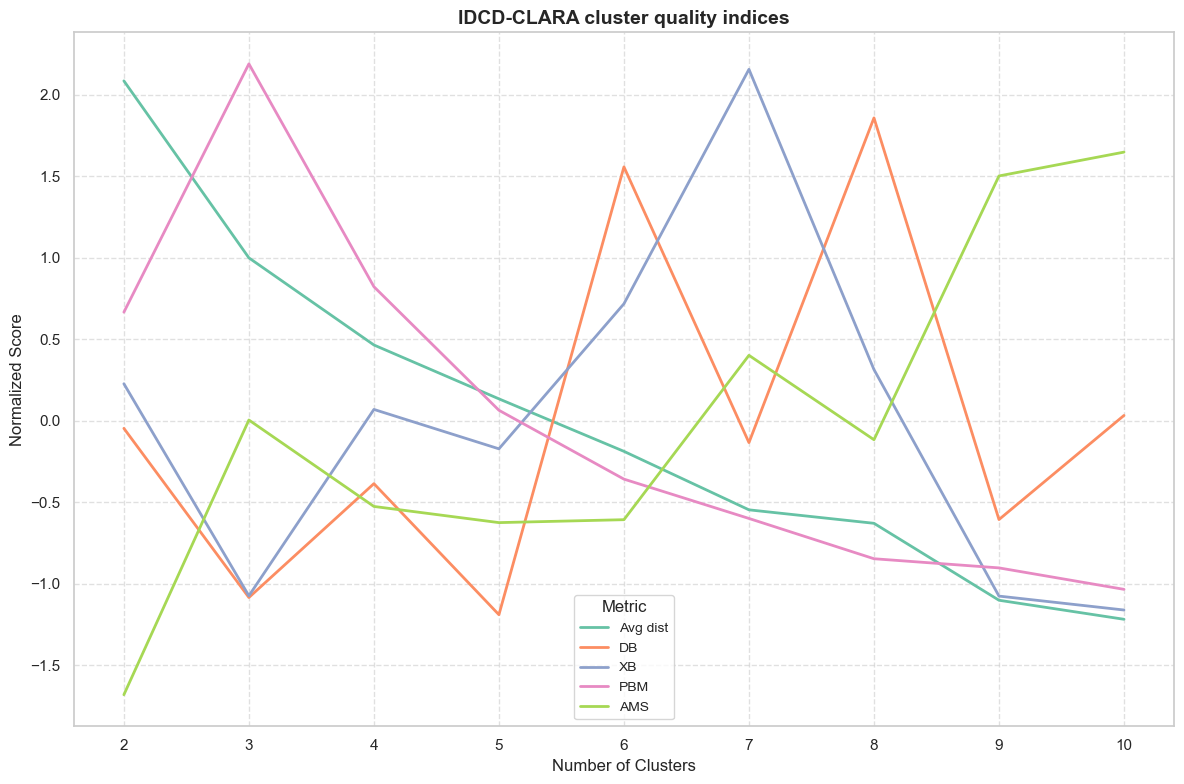

In [10]:
plot_md_clara_quality(
    result,
    title="IDCD-CLARA cluster quality indices",
    save_as=str(OUTPUT_DIR / "idcd_clara_quality.png"),
)


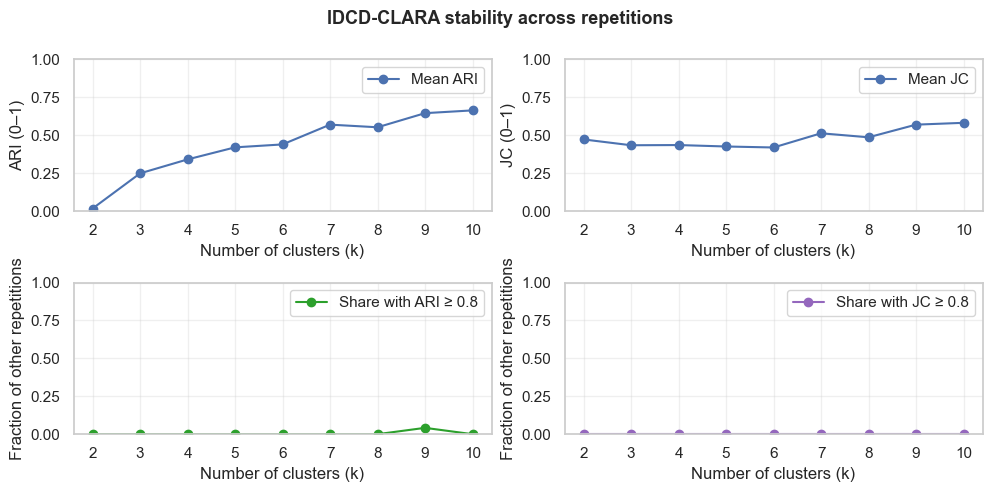

In [11]:
if result.stability:
    from sequenzo.multidomain.clara import plot_md_clara_stability
    plot_md_clara_stability(
        result,
        title="IDCD-CLARA stability across repetitions",
        save_as=str(OUTPUT_DIR / "idcd_clara_stability.png"),
    )


## Step 11 — Choose k and inspect cluster labels

In [12]:
best_k = int(result.stats.loc[result.stats["avg_dist"].idxmin(), "k"])
print(f"Suggested k (lowest avg_dist): {best_k}")

labels = result.best_clustering(best_k)

clustering_df = result.clustering.reset_index().rename(columns={"index": "worker_id"})
cluster_col = f"Cluster {best_k}"
clustering_df["cluster"] = clustering_df[cluster_col]
clustering_df.head()


Suggested k (lowest avg_dist): 10


,worker_id,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,cluster
0,%C2%BBkiran-mummala-narayana-68aaba89,2,2,1,3,4,2,4,8,8,8
1,%E2%86%92-jeremy-mikkola-14455832,2,2,1,3,4,2,4,8,8,8
2,%E2%97%8F%E0%B9%8B-b%C3%A1%DA%A9t%C3%BD%C3%A1v...,1,1,1,1,1,1,1,1,1,1
3,%E5%A4%A7%E4%BB%BB-%E9%99%B3-880a24110,1,1,2,4,5,5,7,4,4,4
4,%EF%BF%BDgary-m-762b16b8,1,1,1,1,1,1,1,1,1,1


## Step 12 — Sequence index plots coloured by cluster

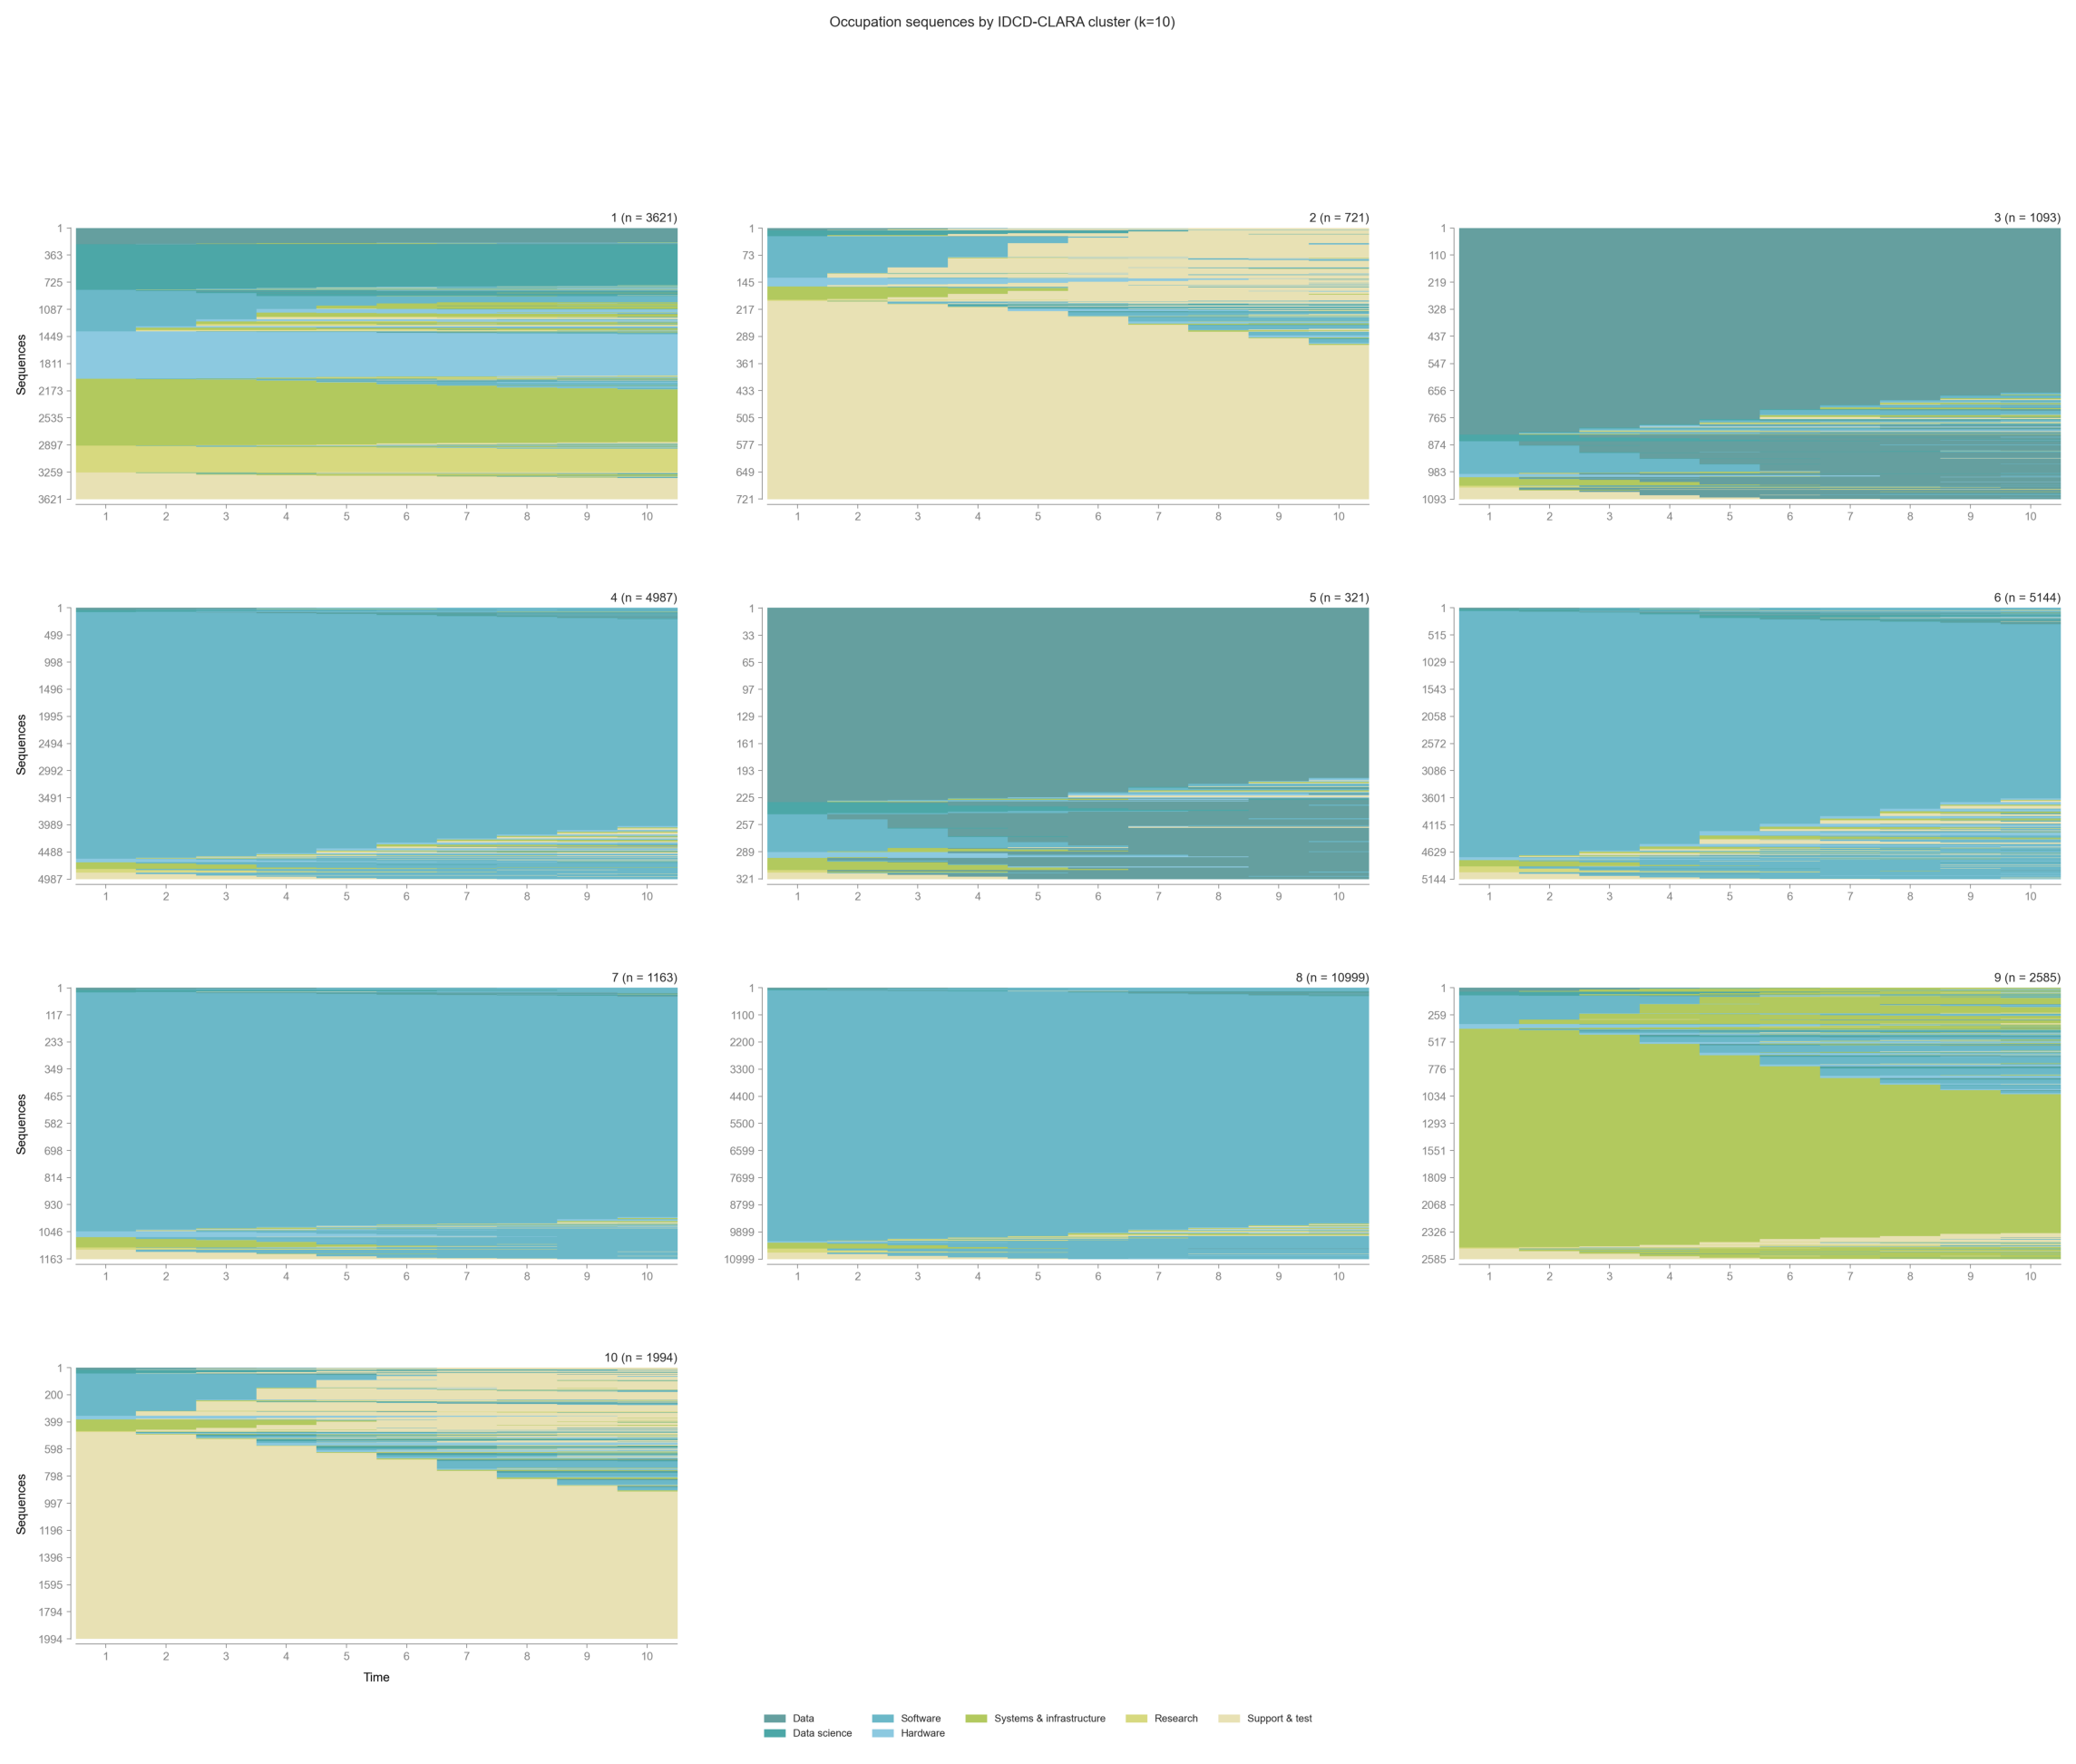

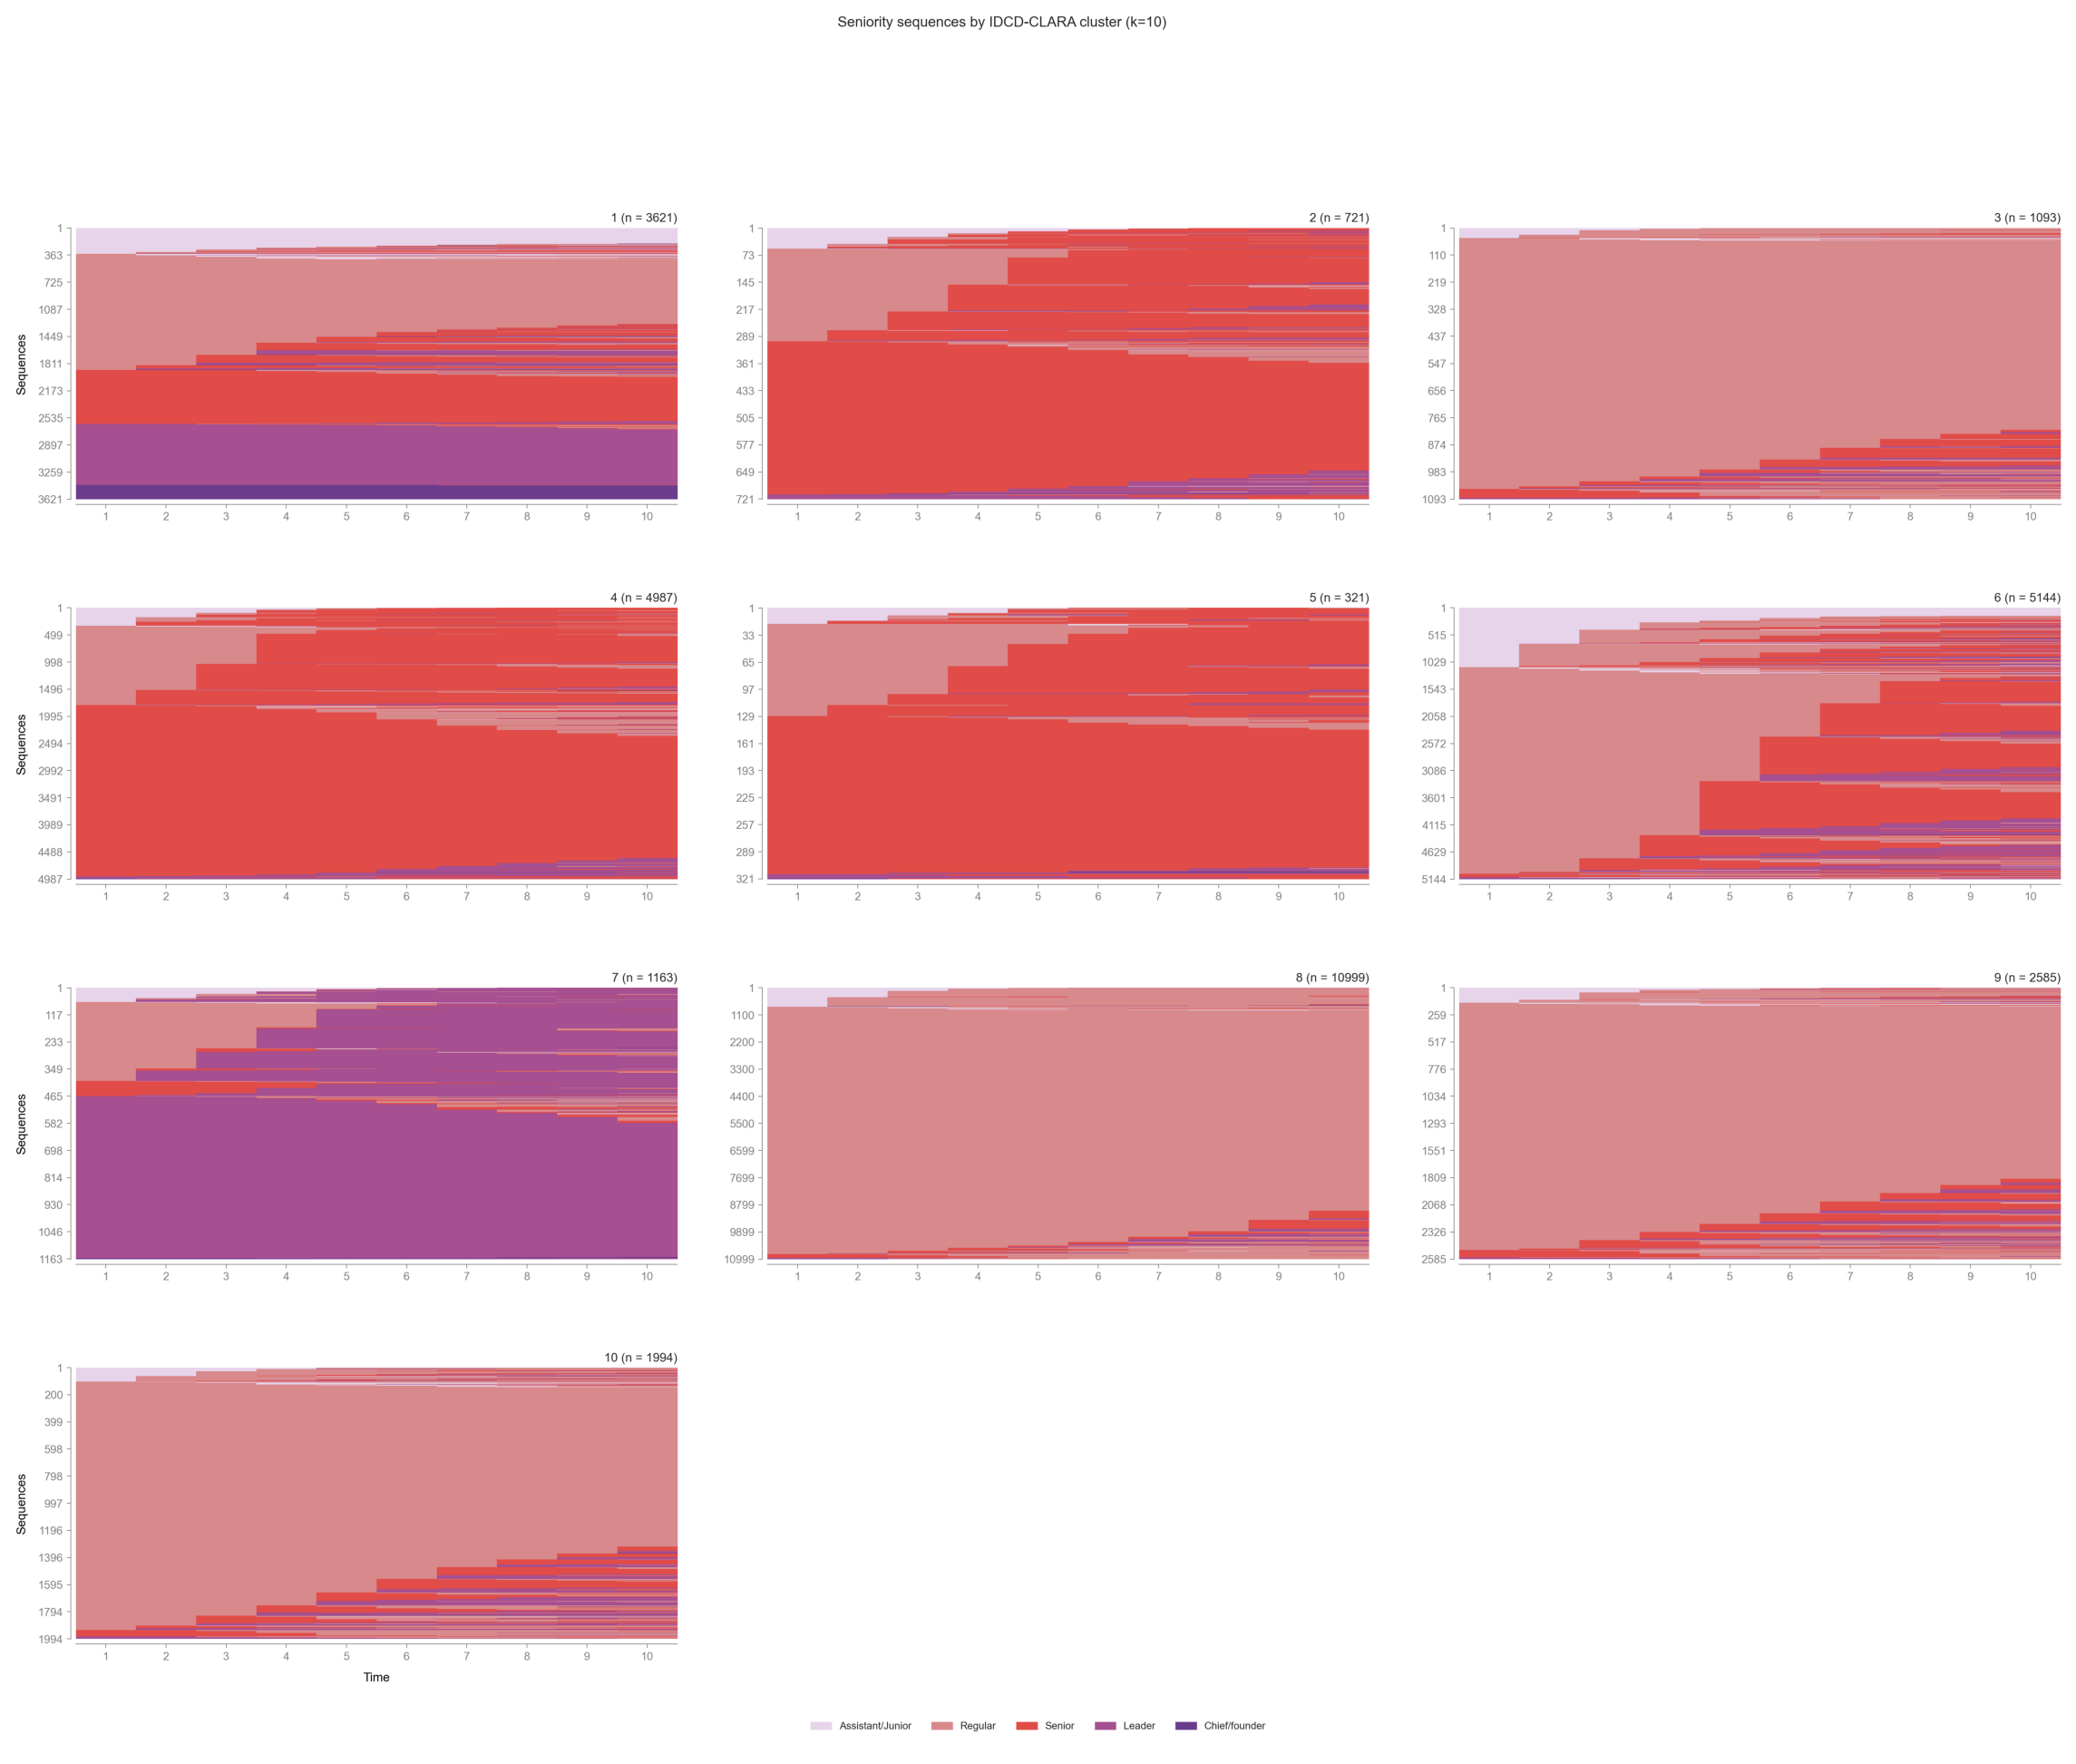

In [13]:
plot_df = occupation_df.merge(
    clustering_df[["worker_id", "cluster"]],
    on="worker_id",
    how="left",
).rename(columns={"worker_id": "Entity ID", "cluster": "Cluster"})

plot_sequence_index(
    seqdata=occupation_seq,
    group_dataframe=plot_df,
    group_column_name="Cluster",
    title=f"Occupation sequences by IDCD-CLARA cluster (k={best_k})",
)

plot_sequence_index(
    seqdata=seniority_seq,
    group_dataframe=plot_df,
    group_column_name="Cluster",
    title=f"Seniority sequences by IDCD-CLARA cluster (k={best_k})",
)


## Leave-one-domain-out stability

Re-fit MD-CLARA after omitting one domain at a time and compare partitions to the **all-domain** solution (ARI). Low agreement suggests the omitted domain carries distinctive typological information. Uses `CLARA_R_DIAG` repetitions to keep runtime manageable.

In [14]:
loo = leave_one_domain_out_sensitivity(
    domains,
    strategy="idcd",
    k=best_k,
    R=CLARA_R_DIAG,
    sample_size=sample_size,
    distance_params=distance_params,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=True,
)
loo["domain"] = [DOMAIN_NAMES[i] for i in loo["omitted_domain_index"]]
loo


[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 7055
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Software+Regular', 'Software+Senior', 'Systems & infrastructure+Regular', 'Support & test+Regular', 'Software+Leader', 'Support & test+Senior', 'Support & test+Leader', 'Data+Regular', 'Systems & infrastructure+Senior', 'Hardware+Regular', 'Software+Assistant/Junior', 'Data science+Regular', 'Hardware+Senior', 'Hardware+Leader', 'Data+Senior', 'Data science+Senior', 'Systems & infrastructure+Leader', 'Research+Regular', 'Research+Assistant/Junior', 'Data science+Leader', 'Data+Leader', 'Hardware+Assistant/Junior', 'Systems & infrastructure+Assistant/Junior', 'Support & test+Assistant/Junior', 'Software+Chief/founder', 'Data science+Assistant/Junior', 'Research+Senior', 'Data+Assistant/Junior', 'R

,omitted_domain,omitted_domain_index,strategy,k,ari_vs_all_domains,jaccard_vs_all_domains,full_requested_sample_size,full_effective_sample_size,full_n_unique_profiles,reduced_requested_sample_size,reduced_effective_sample_size,reduced_n_unique_profiles,reduced_model,domain
0,domain_0,0,idcd,10,0.348938,0.335304,1000,1000,7055,1000,1000,None,clara_single_domain,occupation
1,domain_1,1,idcd,10,0.298731,0.328833,1000,1000,7055,1000,1000,None,clara_single_domain,seniority


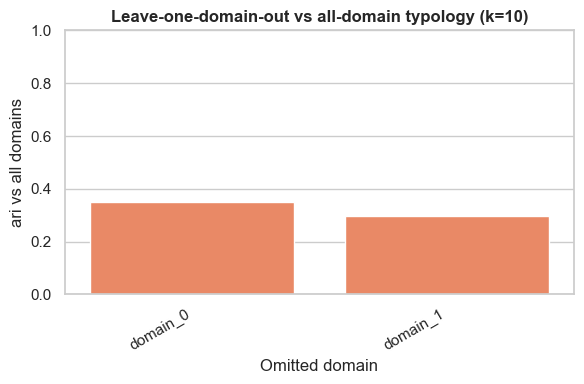

In [15]:
STRATEGY_TAG = "idcd"
plot_leave_one_domain_out_sensitivity(
    loo,
    metric="ari_vs_all_domains",
    title=f"Leave-one-domain-out vs all-domain typology (k={best_k})",
    save_as=str(OUTPUT_DIR / f"idcd_loo_sensitivity_k{best_k}.png"),
)
plt.show()


## Step 13 — Save results

In [16]:
result.stats.to_csv(OUTPUT_DIR / "idcd_clara_stats.csv", index=False)
clustering_df.to_csv(OUTPUT_DIR / f"idcd_clara_clustering_k{best_k}.csv", index=False)
print("Saved outputs to", OUTPUT_DIR)
loo.to_csv(OUTPUT_DIR / f"idcd_loo_sensitivity_k{best_k}.csv", index=False)
if result.combined_state_space:
    pd.DataFrame([result.combined_state_space]).to_csv(
        OUTPUT_DIR / "idcd_combined_state_space.csv", index=False
    )


Saved outputs to /Users/xinyi/Projects/sequenzo/sequenzo/sequenzo310/Sequenzo/tests/archive_test/xinyi_test/outputs


---

### What you learned

- **IDCD** combines domains at the **state** level before distance computation.
- **MD-CLARA** scales IDCD without materializing the full pairwise distance object.
- **`summarize_combined_state_space`** and `combined_state_space=True` help assess sparsity of the combined alphabet.
- **`leave_one_domain_out_sensitivity`** checks whether each domain is essential to the joint typology.
- Cross-strategy agreement on the same data: `md_clara_cross_strategy_diagnostics.ipynb`.
- Compare with `cat_md_clara_tutorial.ipynb` and `dat_md_clara_tutorial.ipynb`.